<a href="https://colab.research.google.com/github/Drankenstain/portofolio/blob/main/Spark_SQL_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql.functions import *
from pyspark.sql import SparkSession
from matplotlib import pyplot as plt
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import when

In [ ]:
spark = SparkSession.builder.getOrCreate()

In [ ]:
#Import Dataset
MsVictim = spark.read.csv("MsVictim.csv", header=True, inferSchema=True)
MsPoliceOffice = spark.read.csv("MsPoliceOffice.csv", header=True, inferSchema=True)
MsPolice = spark.read.csv("MsPolice.csv", header=True, inferSchema=True)
MsCaseType = spark.read.csv("MsCaseType.csv", header=True, inferSchema=True)
CaseHeader = spark.read.csv("CaseHeader.csv", header=True, inferSchema=True)
CaseDetail = spark.read.csv("CaseDetail.csv", header=True, inferSchema=True)

In [ ]:
#RegisterTable
MsVictim.registerTempTable("MsVictim")
MsPoliceOffice.registerTempTable("MsPoliceOffice")
MsPolice.registerTempTable("MsPolice")
MsCaseType.registerTempTable("MsCaseType")
CaseHeader.registerTempTable("CaseHeader")
CaseDetail.registerTempTable("CaseDetail")

+--------------------+--------------+
|Police Office Region|Number of Case|
+--------------------+--------------+
|          California|            30|
|             Arizona|            28|
|             Florida|            28|
|            Nebraska|            28|
|              Oregon|            23|
+--------------------+--------------+



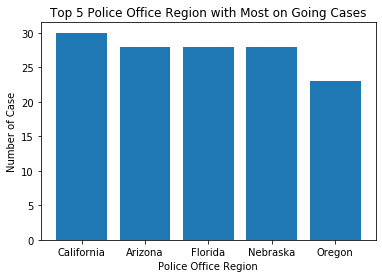

In [ ]:
#a.	Show the top 5 police office regions that have the most ongoing cases using a bar plot.

result = spark.sql("""
    SELECT PoliceOfficeRegion AS `Police Office Region`, COUNT(ch.CaseID) AS `Number of Case`
    FROM CaseHeader ch
    JOIN CaseDetail cd ON ch.CaseID = cd.CaseID
    JOIN MsPolice mp ON mp.PoliceID = cd.PoliceID
    JOIN MsPoliceOffice mpo ON mpo.PoliceOfficeID = mp.PoliceOfficeID
    WHERE ch.CaseStatus = 'On Going'
    GROUP BY PoliceOfficeRegion
    ORDER BY `Number of Case` DESC, PoliceOfficeRegion
    LIMIT 5
""")

result.show()

# Pakai backtick(yg dibawah esc)
pd_result = result.toPandas()
plt.title("Top 5 Police Office Region with Most on Going Cases")
plt.bar(pd_result["Police Office Region"], pd_result["Number of Case"])
plt.xlabel("Police Office Region")
plt.ylabel("Number of Case")
plt.show()

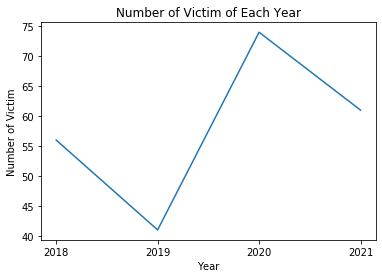

In [ ]:
#b.	Show the total number of victims for each year where the police office region is in Nevada, Washington, Oregon, and California using a line plot.

result = spark.sql("""
    SELECT YEAR(CaseDate) AS `Year`, COUNT(VictimID) AS `Total Victim`
    FROM CaseHeader ch
    JOIN MsVictim mv ON ch.CaseID = mv.CaseID
    JOIN CaseDetail cd ON ch.CaseID = cd.CaseID
    JOIN MsPolice mp ON mp.PoliceID = cd.PoliceID
    JOIN MsPoliceOffice mpo ON mpo.PoliceOfficeID = mp.PoliceOfficeID
    WHERE PoliceOfficeRegion IN ('Nevada', 'Washington', 'Oregon', 'California')
    GROUP BY `Year`
""")

pd_result = result.toPandas()

plt.plot(pd_result["Year"], pd_result["Total Victim"])
plt.xticks(pd_result["Year"])
plt.title("Number of Victim of Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Victim")
plt.show()

+------------+------------+
|   CrimeType|Total Victim|
+------------+------------+
|Misdemeanors|          52|
|   Violation|          56|
|    Felonies|         128|
+------------+------------+



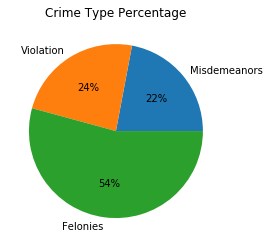

In [ ]:
result = spark.sql("""
    WITH Crime AS (
    SELECT CaseTypeName,
    CASE
        WHEN CaseTypeName IN ("Robbery", "Drug", "Burglary") THEN 'Violation'
        WHEN CaseTypeName IN ("Fraud and Scam", "Family Violance", "White-Colar Crime") THEN 'Misdemeanors'
        WHEN CaseTypeName IN ("Murder", "Cybercrime", "Terrorism", "Foreign Counterintelligence") THEN 'Felonies'
    END AS CrimeType FROM MsCaseType
), NumberOfCase AS (
    SELECT CaseTypeName, COUNT(mv.VictimID) as TotalVictim FROM MsVictim mv
    JOIN CaseHeader ch ON mv.CaseID = ch.CaseID
    JOIN MsCaseType mct ON ch.CaseTypeID = mct.CaseTypeID
    GROUP BY CaseTypeName
    HAVING TotalVictim > 50
)

SELECT CrimeType, SUM(TotalVictim) AS `Total Victim` FROM Crime c
JOIN NumberOfCase noc ON c.CaseTypeName = noc.CaseTypeName
GROUP BY CrimeType
""")

result.show()

pd_result = result.toPandas()
plt.pie(pd_result["Total Victim"], labels=pd_result["CrimeType"], autopct="%.f%%")
plt.title("Crime Type Percentage")
plt.show()

In [ ]:
result = spark.sql("""
    SELECT CaseTypeName, COUNT(mv.VictimID) as TotalVictim FROM MsVictim mv
    JOIN CaseHeader ch ON mv.CaseID = ch.CaseID
    JOIN MsCaseType mct ON ch.CaseTypeID = mct.CaseTypeID
    GROUP BY CaseTypeName
""")

result.show()

+--------------------+-----------+
|        CaseTypeName|TotalVictim|
+--------------------+-----------+
|Foreign Counterin...|         66|
|   White-Colar Crime|         52|
|             Robbery|         40|
|                Drug|         37|
|            Burglary|         56|
|          Cybercrime|         62|
|              Murder|         49|
|           Terrorism|         49|
|      Fraud and Scam|         46|
|     Family Violence|         43|
+--------------------+-----------+



In [ ]:
# Clustering Model

In [ ]:
df_train = spark.read.csv("Dataset.csv", header=True, inferSchema=True)

In [ ]:
df_train = df_train.na.drop()

In [ ]:
df_train = df_train.select("sugar_level", "calories", "fat")
df_train.show()

+--------------------+--------+-----+
|         sugar_level|calories|  fat|
+--------------------+--------+-----+
|145.7699999999999...| 764 cal|46 gr|
|-4.60000000000000...| 262 cal|24 gr|
|            95.81 gr| 448 cal|27 gr|
|           100.16 gr| 375 cal|11 gr|
|-8.56000000000000...|  93 cal|26 gr|
|           140.24 gr| 651 cal|24 gr|
|35.26000000000000...| 331 cal|32 gr|
|            35.47 gr| 245 cal|28 gr|
|59.76000000000000...| 771 cal|24 gr|
|-7.60999999999999...|  99 cal| 4 gr|
|96.58000000000001 gr| 506 cal|26 gr|
|5.180000000000007 gr| 459 cal|19 gr|
|100.4199999999999...| 346 cal|15 gr|
|116.7899999999999...| 436 cal|36 gr|
|            86.53 gr| 312 cal|38 gr|
|           142.05 gr| 430 cal|36 gr|
|97.00999999999999 gr| 262 cal|31 gr|
|           150.36 gr| 384 cal|19 gr|
|            137.2 gr| 679 cal|44 gr|
|99.47999999999999 gr| 361 cal| 2 gr|
+--------------------+--------+-----+
only showing top 20 rows



In [ ]:
#Data Transforming

df_train = df_train.withColumn("sugar_level", regexp_replace(col("sugar_level"), " gr", ""))
df_train = df_train.withColumn("calories", regexp_replace(col("calories"), " cal", ""))
df_train = df_train.withColumn("fat", regexp_replace(col("fat"), " gr", ""))

df_train = df_train.withColumn("sugar_level", df_train["sugar_level"].cast("float"))
df_train = df_train.withColumn("calories", df_train["calories"].cast("int"))
df_train = df_train.withColumn("fat", df_train["fat"].cast("int"))
df_train.show()

+-----------+--------+---+
|sugar_level|calories|fat|
+-----------+--------+---+
|     145.77|     764| 46|
|       -4.6|     262| 24|
|      95.81|     448| 27|
|     100.16|     375| 11|
|      -8.56|      93| 26|
|     140.24|     651| 24|
|      35.26|     331| 32|
|      35.47|     245| 28|
|      59.76|     771| 24|
|      -7.61|      99|  4|
|      96.58|     506| 26|
|       5.18|     459| 19|
|     100.42|     346| 15|
|     116.79|     436| 36|
|      86.53|     312| 38|
|     142.05|     430| 36|
|      97.01|     262| 31|
|     150.36|     384| 19|
|      137.2|     679| 44|
|      99.48|     361|  2|
+-----------+--------+---+
only showing top 20 rows



In [ ]:
#Vectoring Data

cols = df_train.columns
df_train = VectorAssembler(inputCols = cols, outputCol = 'FeaturesVector').transform(df_train)

In [ ]:
# Data Normalization
scaler = StandardScaler(inputCol = 'FeaturesVector', outputCol = 'features')
df_train = scaler.fit(df_train).transform(df_train)

df_train.show()

+-----------+--------+---+--------------------+--------------------+
|sugar_level|calories|fat|      FeaturesVector|            features|
+-----------+--------+---+--------------------+--------------------+
|     145.77|     764| 46|[145.770004272460...|[3.08675782677738...|
|       -4.6|     262| 24|[-4.5999999046325...|[-0.0974074589602...|
|      95.81|     448| 27|[95.8099975585937...|[2.02882795622846...|
|     100.16|     375| 11|[100.160003662109...|[2.12094166270444...|
|      -8.56|      93| 26|[-8.5600004196167...|[-0.1812625884477...|
|     140.24|     651| 24|[140.240005493164...|[2.96965714410086...|
|      35.26|     331| 32|[35.2599983215332...|[0.74664932840172...|
|      35.47|     245| 28|[35.4700012207031...|[0.75109625214227...|
|      59.76|     771| 24|[59.7599983215332...|[1.26544993579344...|
|      -7.61|      99|  4|[-7.6100001335144...|[-0.1611458241436...|
|      96.58|     506| 26|[96.5800018310546...|[2.04513320864670...|
|       5.18|     459| 19|[5.17999

In [ ]:
#Generate Model
kmeans = KMeans().setK(2)
model = kmeans.fit(df_train).transform(df_train)
model.show()

+-----------+--------+---+--------------------+--------------------+----------+
|sugar_level|calories|fat|      FeaturesVector|            features|prediction|
+-----------+--------+---+--------------------+--------------------+----------+
|     145.77|     764| 46|[145.770004272460...|[3.08675782677738...|         1|
|       -4.6|     262| 24|[-4.5999999046325...|[-0.0974074589602...|         0|
|      95.81|     448| 27|[95.8099975585937...|[2.02882795622846...|         1|
|     100.16|     375| 11|[100.160003662109...|[2.12094166270444...|         0|
|      -8.56|      93| 26|[-8.5600004196167...|[-0.1812625884477...|         0|
|     140.24|     651| 24|[140.240005493164...|[2.96965714410086...|         1|
|      35.26|     331| 32|[35.2599983215332...|[0.74664932840172...|         0|
|      35.47|     245| 28|[35.4700012207031...|[0.75109625214227...|         0|
|      59.76|     771| 24|[59.7599983215332...|[1.26544993579344...|         1|
|      -7.61|      99|  4|[-7.6100001335

      sugar_level  calories  fat                     FeaturesVector  \
0      145.770004       764   46  [145.77000427246094, 764.0, 46.0]   
1       -4.600000       262   24  [-4.599999904632568, 262.0, 24.0]   
2       95.809998       448   27   [95.80999755859375, 448.0, 27.0]   
3      100.160004       375   11  [100.16000366210938, 375.0, 11.0]   
4       -8.560000        93   26     [-8.5600004196167, 93.0, 26.0]   
...           ...       ...  ...                                ...   
9489   123.699997       283   23  [123.69999694824219, 283.0, 23.0]   
9490   101.540001       401   39  [101.54000091552734, 401.0, 39.0]   
9491    32.910000       530   14   [32.90999984741211, 530.0, 14.0]   
9492    24.190001        26   26   [24.190000534057617, 26.0, 26.0]   
9493    82.320000       336   29   [82.31999969482422, 336.0, 29.0]   

                                               features  prediction  
0     [3.0867578267773816, 4.040470573405915, 3.4913...           1  
1     [

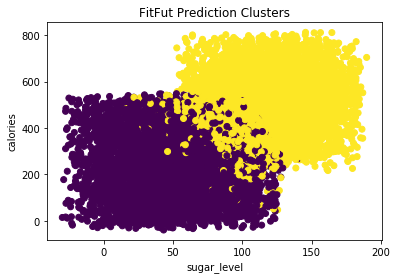

In [ ]:
#Visualization
fp = model.toPandas()
print(fp)

#Visualization with Plot
plt.scatter(fp["sugar_level"],
            fp["calories"],
            c=fp["prediction"]
           )

plt.title("FitFut Prediction Clusters")
plt.xlabel("sugar_level")
plt.ylabel("calories")
plt.show()